<a href="https://colab.research.google.com/github/newh08/AI_Voyage/blob/main/CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##[MYCODE] 데이터를 CIFAR10 으로 변경하기

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms

transform = transforms.ToTensor()

trainset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform
)

100%|██████████| 170498071/170498071 [02:18<00:00, 1229710.47it/s]


Extracting ./data/cifar-10-python.tar.gz to ./data


##[LOG] CIFAR10 데이터 출력해보기

50000
torch.Size([3, 32, 32])


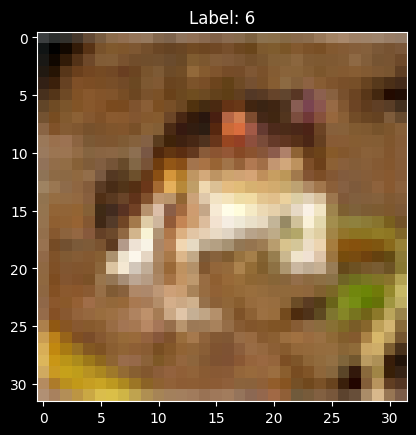

In [ ]:
from matplotlib import pyplot as plt


print(len(trainset))
print(trainset[0][0].shape)
# CIFAR-10 이미지 출력
# torch.Tensor는 (체널, 높이, 너비) 순서 에서 matplotlib 에서 쓰이는 (높이, 너비, 채널) 로 변경
plt.imshow(trainset[0][0].permute(1, 2, 0))
plt.title(f"Label: {trainset[0][1]}")
plt.show()

[LOG] 배치 생성후 출력해 입력을 어떻게 할지 확인해보기

In [ ]:
batch_size = 256

trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)

dataiter = iter(trainloader)
images, labels = next(dataiter)
print(images.shape, labels.shape)

torch.Size([256, 3, 32, 32]) torch.Size([256])
Files already downloaded and verified


##[MYCODE] 테스트용 데이터 및 배치 생성하기

In [ ]:
testset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform
)

testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False)

##[MYCODE] 모델 정의 및 평가 함수, 시각화 함수 정의하기

In [ ]:
from torch import nn
from torch.optim import SGD
from torch.optim import Adam
import numpy as np


def accuracy(model, dataloader):  # 평가 함수 정의
    cnt = 0
    acc = 0

    for data in dataloader:
        inputs, labels = data

        preds = model(inputs)
        preds = torch.argmax(preds, dim=-1)

        cnt += labels.shape[0]
        acc += (labels == preds).sum().item()

    return acc / cnt


def plot_acc(
    accs_1, accs_2, accs_3, accs_4, label1, label2, label3, label4
):  # 시각화 함수 정의
    x = np.arange(len(accs_1))

    plt.plot(x, accs_1, label=label1)
    plt.plot(x, accs_2, label=label2)
    if accs_3 != None:
        plt.plot(x, accs_3, label=label3)
    if accs_4 != None:
        plt.plot(x, accs_4, label=label4)
    plt.legend()
    plt.show()


def acc_and_plot(model1, model2, label1, label2, dataloader):
    model1_list = []
    model2_list = []

    model1_acc = accuracy(model1, dataloader)
    model1_list.append(model1_acc)

    model2_acc = accuracy(model2, dataloader)
    model2_list.append(model2_acc)

    plot_acc(model1_list, model2_list, None, None, label1, label2, None, None)


# 모델 정의 활성함수를 파라미터로 넣을수 있도록 설계
class Model(nn.Module):
    def __init__(self, input_dim, n_dim, active_function):
        super().__init__()

        self.layer1 = nn.Linear(input_dim, n_dim)
        self.layer2 = nn.Linear(n_dim, n_dim)
        self.layer3 = nn.Linear(n_dim, 10)
        self.act = active_function

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        x = self.act(self.layer1(x))
        x = self.act(self.layer2(x))
        x = self.layer3(x)

        return x

## [LOG] Plot 1. 최적화 함수 비교, SGD 와 Adam 학습 후 정확도 출력하기

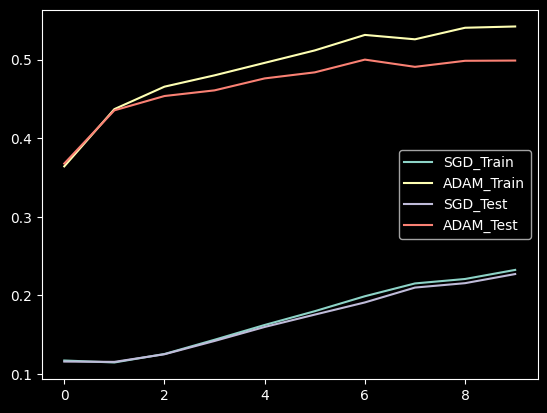

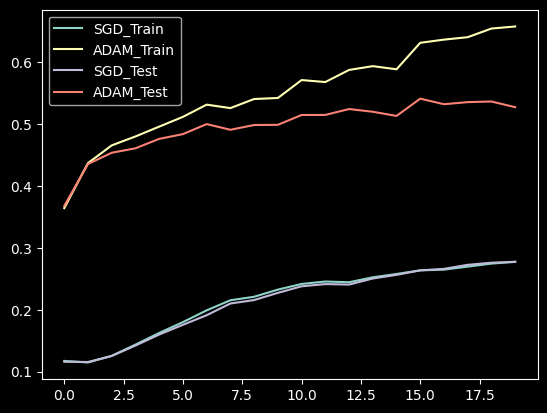

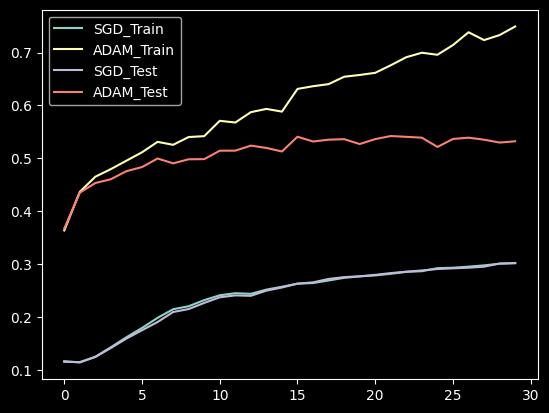

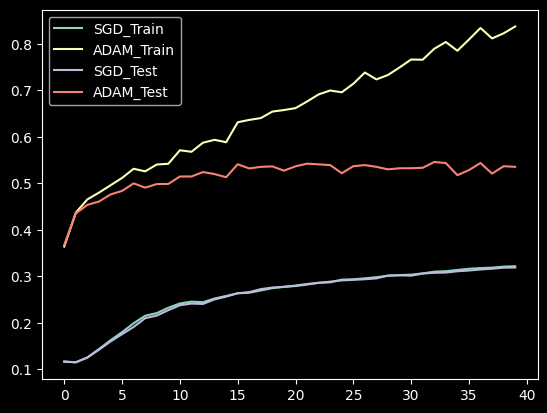

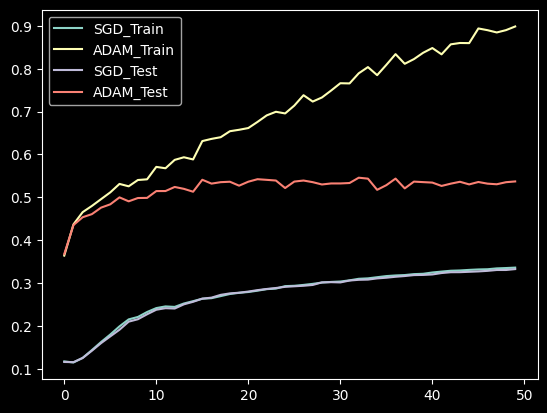

In [ ]:
# 모델 구현
leaky_relu_model_sgd = Model(32 * 32 * 3, 1024, nn.LeakyReLU())
leaky_relu_model_sgd = leaky_relu_model_sgd.to("cuda")
leaky_relu_model_adam = Model(32 * 32 * 3, 1024, nn.LeakyReLU())
leaky_relu_model_adam = leaky_relu_model_adam.to("cuda")

# 최적화 함수 정의
lr = 0.001
sgd_optimizer = SGD(leaky_relu_model_sgd.parameters(), lr=lr)
adam_optimizer = Adam(leaky_relu_model_adam.parameters(), lr=lr)

n_epochs = 50
criterion = nn.CrossEntropyLoss()  # 손실함수 정의

sgd_acc_train_list = []
adam_acc_train_list = []
sgd_accuracy_list = []
adam_accuracy_list = []


for epoch in range(n_epochs):

    for data in trainloader:

        inputs, labels = data
        inputs, labels = inputs.to("cuda"), labels.to("cuda")
        sgd_optimizer.zero_grad()

        sgd_preds = leaky_relu_model_sgd(inputs)
        sgd_loss = criterion(sgd_preds, labels)
        sgd_loss.backward()
        sgd_optimizer.step()

        adam_optimizer.zero_grad()

        adam_prds = leaky_relu_model_adam(inputs)
        adam_loss = criterion(adam_prds, labels)
        adam_loss.backward()
        adam_optimizer.step()

    sgd_acc_train = accuracy(leaky_relu_model_sgd, trainloader)
    sgd_acc_train_list.append(sgd_acc_train)
    adam_acc_train = accuracy(leaky_relu_model_adam, trainloader)
    adam_acc_train_list.append(adam_acc_train)
    sgd_accuracy = accuracy(leaky_relu_model_sgd, testloader)
    sgd_accuracy_list.append(sgd_accuracy)
    adam_accuracy = accuracy(leaky_relu_model_adam, testloader)
    adam_accuracy_list.append(adam_accuracy)

    if (epoch + 1) % 10 == 0:  # 10 epoch마다 그래프 업데이트
        plot_acc(
            sgd_acc_train_list,
            adam_acc_train_list,
            sgd_accuracy_list,
            adam_accuracy_list,
            "SGD_Train",
            "ADAM_Train",
            "SGD_Test",
            "ADAM_Test",
        )

##[FEEDBACK] CrossEntropyLoss 손실함수에 넣어주는 값이 10차원 텐서인 출력값과 라벨인 숫자1자리 일 것같은데, 이 둘 사이의 맵핑이 어떻게 이루어지나요? 단순히 6 이면 텐서에서 6번째 숫자 로 맵핑일까요?

##[FEEDBACK] ADAM 에서 학습이 진행되어도 성공률이 진동하는 이유..?

##[FEEDBACK] lr 을 조절하니 SGD 에서 학습진행 대비 성공률이 크게 달라지는걸 로그로 확인해봤습니다. 여기서 lr 조절의 의미는 최적화 함수에서 파라미터를 변화시키는 크기를 조절한다고 이해해도 괜찮을까요?

## [LOG] Plot 2. 활성화 함수 비교, sigmoid 와 leaky ReLU 비교하기

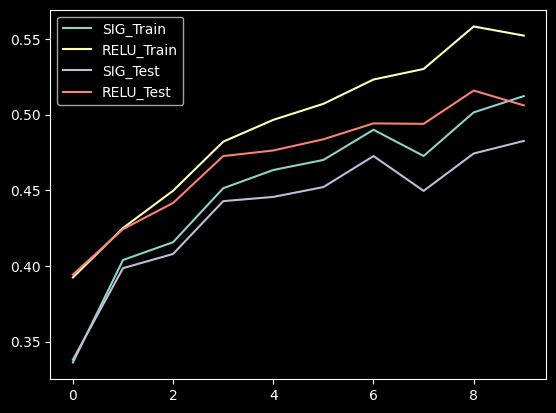

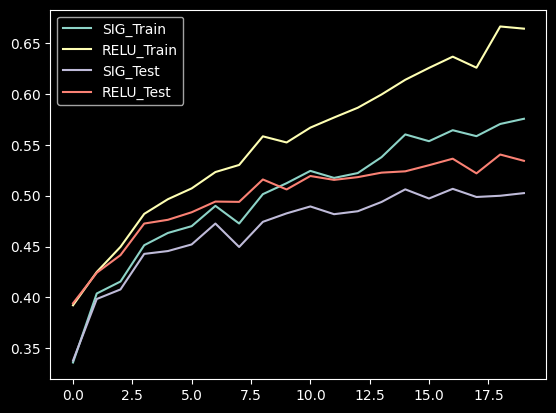

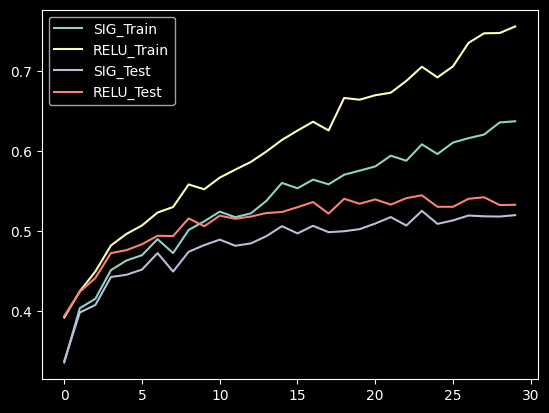

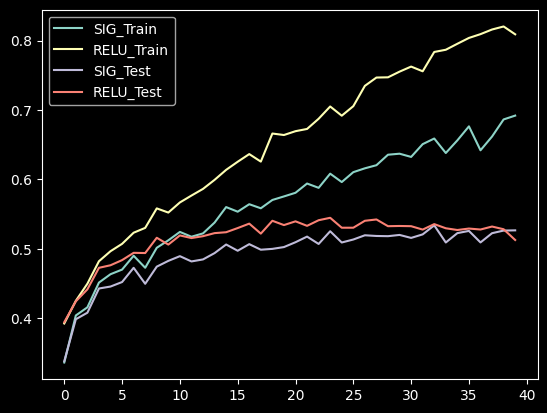

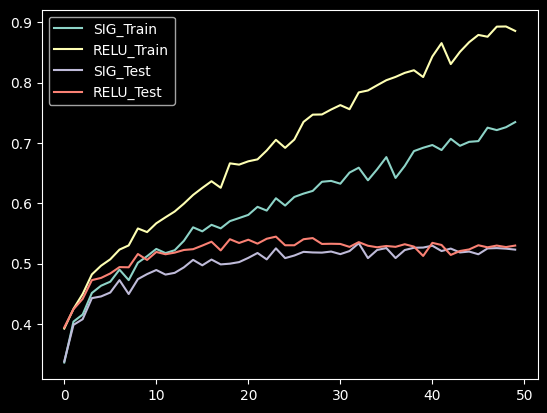

In [ ]:
sigmoid_model_adam = Model(32 * 32 * 3, 1024, nn.Sigmoid())
sigmoid_model_adam = sigmoid_model_adam.to("cuda")
leaky_relu_model_adam_2 = Model(32 * 32 * 3, 1024, nn.LeakyReLU())
leaky_relu_model_adam_2 = leaky_relu_model_adam_2.to("cuda")

sig_adam_optimizer = Adam(sigmoid_model_adam.parameters(), lr=lr)
relu_adam_optimizer = Adam(leaky_relu_model_adam_2.parameters(), lr=lr)

sig_acc_train_list = []
relu_acc_train_list = []
sigAccuracyList = []
reluAccuracyList = []

for epoch in range(n_epochs):

    for data in trainloader:

        inputs, labels = data
        inputs, labels = inputs.to("cuda"), labels.to("cuda")

        sig_adam_optimizer.zero_grad()

        sig_preds = sigmoid_model_adam(inputs)
        sig_loss = criterion(sig_preds, labels)
        sig_loss.backward()
        sig_adam_optimizer.step()

        relu_adam_optimizer.zero_grad()

        relu_prds = leaky_relu_model_adam_2(inputs)
        relu_loss = criterion(relu_prds, labels)
        relu_loss.backward()
        relu_adam_optimizer.step()

    sig_acc_train = accuracy(sigmoid_model_adam, trainloader)
    sig_acc_train_list.append(sig_acc_train)
    relu_acc_train = accuracy(leaky_relu_model_adam_2, trainloader)
    relu_acc_train_list.append(relu_acc_train)

    sig_accuracy = accuracy(sigmoid_model_adam, testloader)
    sigAccuracyList.append(sig_accuracy)
    relu_accuracy = accuracy(leaky_relu_model_adam_2, testloader)
    reluAccuracyList.append(relu_accuracy)

    if (epoch + 1) % 10 == 0:  # 10 epoch마다 그래프 업데이트
        plot_acc(
            sig_acc_train_list,
            relu_acc_train_list,
            sigAccuracyList,
            reluAccuracyList,
            "SIG_Train",
            "RELU_Train",
            "SIG_Test",
            "RELU_Test",
        )

## [LOG] Dropout 적용해 train 과 test 정확도 비교하기

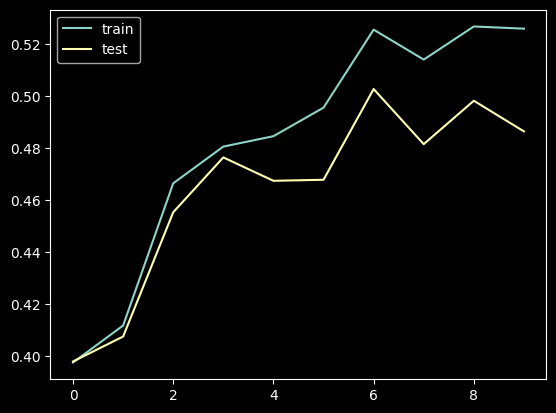

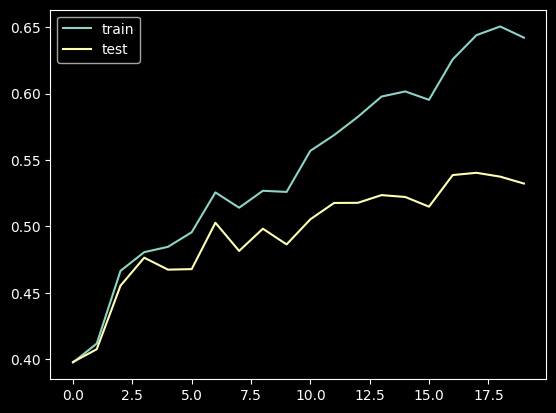

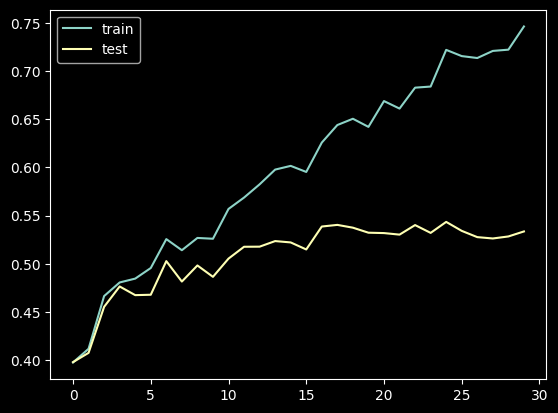

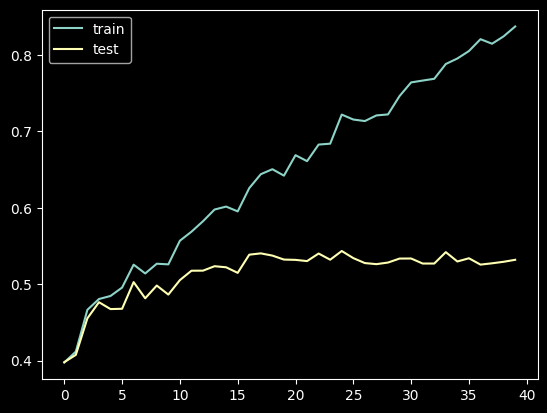

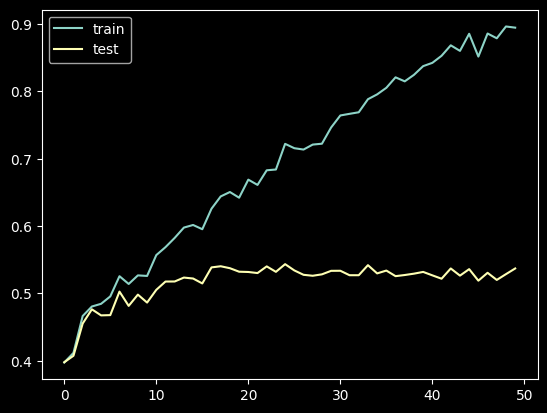

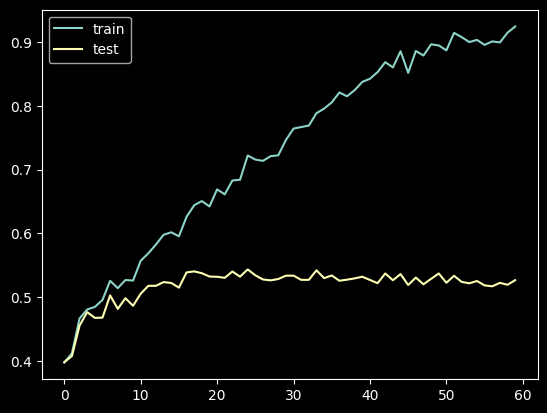

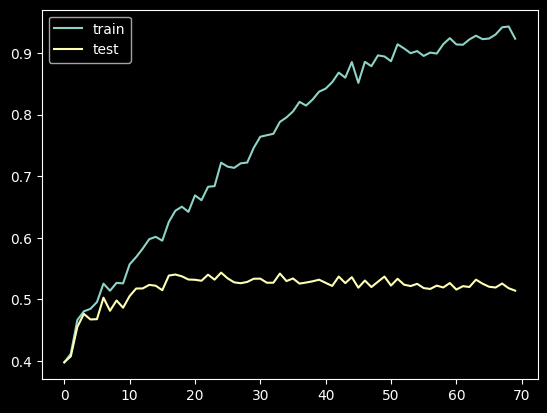

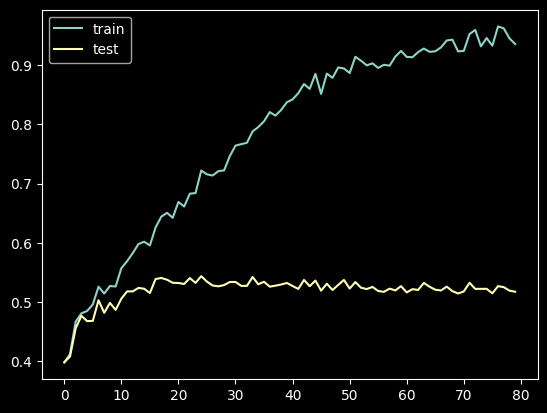

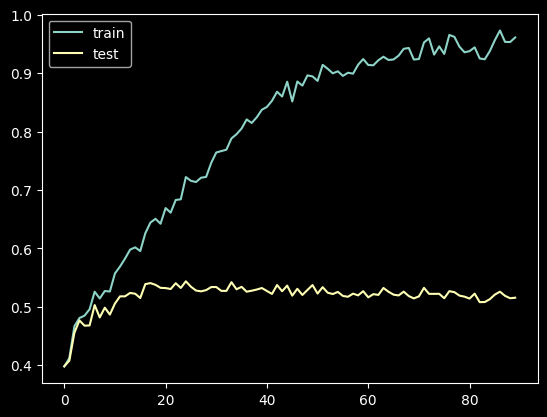

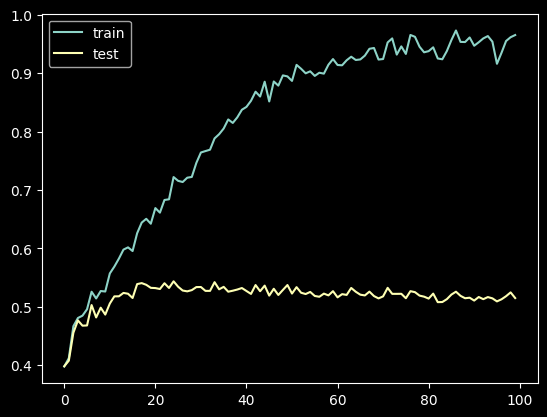

In [ ]:
class DropoutModel(nn.Module):
    def __init__(self, input_dim, n_dim, active_function, dropout_prob=0.1):
        super().__init__()

        self.layer1 = nn.Linear(input_dim, n_dim)
        self.dropout1 = nn.Dropout(dropout_prob)

        self.layer2 = nn.Linear(n_dim, n_dim)
        self.dropout2 = nn.Dropout(dropout_prob)

        self.layer3 = nn.Linear(n_dim, 10)
        self.act = active_function

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        x = self.act(self.layer1(x))
        x = self.dropout1(x)

        x = self.act(self.layer2(x))
        x = self.dropout2(x)
        x = self.layer3(x)

        return x


dropout_model_relu = Model(32 * 32 * 3, 1024, nn.LeakyReLU())
dropout_model_relu = dropout_model_relu.to("cuda")

relu_adam_dropout_optimizer = Adam(dropout_model_relu.parameters(), lr=lr)

dropout_accuracyList_train = []
dropout_accuracyList_test = []

for epoch in range(n_epochs):
    dropout_model_relu.train()
    for data in trainloader:

        inputs, labels = data
        inputs, labels = inputs.to("cuda"), labels.to("cuda")
        relu_adam_dropout_optimizer.zero_grad()

        drop_preds = dropout_model_relu(inputs)
        drop_loss = criterion(drop_preds, labels)
        drop_loss.backward()
        relu_adam_dropout_optimizer.step()

    with torch.no_grad():
        dropout_model_relu.eval()
        drop_accuracy_train = accuracy(dropout_model_relu, trainloader)
        dropout_accuracyList_train.append(drop_accuracy_train)
        drop_accuracy_test = accuracy(dropout_model_relu, testloader)
        dropout_accuracyList_test.append(drop_accuracy_test)

    if (epoch + 1) % 10 == 0:  # 10 epoch마다 그래프 업데이트
        plot_acc(
            dropout_accuracyList_train,
            dropout_accuracyList_test,
            None,
            None,
            "train",
            "test",
            None,
            None,
        )